In [1]:
# Cell 1: Imports
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device}")

Using: cuda


In [2]:
# Cell 2: Load CIFAR-10
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:14<00:00, 11.4MB/s]


In [3]:
# Cell 3: Helper Functions
def get_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def train_model(model, loader, optimizer, criterion, max_epochs=30, patience=5):
    train_losses = []
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{max_epochs} - Loss: {avg_loss:.4f}")

        # Early Stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return train_losses

In [4]:
# Cell 4: Load ResNet18 and count parameters
model = resnet18(pretrained=True)
model.fc = nn.Linear(512, 10)
model = model.to(device)

param_count = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Parameter count: {param_count:.2f} M")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]


Parameter count: 11.18 M


In [5]:
# Cell 5: LINEAR PROBE
# Freeze all layers except last
for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

print("=== Training Linear Probe ===")
start = time.time()
lp_losses = train_model(model, trainloader, optimizer, criterion, max_epochs=10, patience=3)
lp_time = time.time() - start

lp_accuracy = get_accuracy(model, testloader)
print(f"Linear Probe Accuracy: {lp_accuracy:.2f}%")

=== Training Linear Probe ===
Epoch 1/10 - Loss: 0.8299
Epoch 2/10 - Loss: 0.6196
Epoch 3/10 - Loss: 0.5885
Epoch 4/10 - Loss: 0.5788
Epoch 5/10 - Loss: 0.5690
Epoch 6/10 - Loss: 0.5597
Epoch 7/10 - Loss: 0.5559
Epoch 8/10 - Loss: 0.5496
Epoch 9/10 - Loss: 0.5468
Epoch 10/10 - Loss: 0.5459
Linear Probe Accuracy: 80.66%


In [6]:
# Cell 6: FINE-TUNE (unfreeze last few layers)
# Unfreeze last 2 layers + fc
for name, param in model.named_parameters():
    if any(x in name for x in ['layer4', 'fc']):
        param.requires_grad = True

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

print("=== Training Fine-tune ===")
start = time.time()
ft_losses = train_model(model, trainloader, optimizer, criterion, max_epochs=10, patience=3)
ft_time = time.time() - start

ft_accuracy = get_accuracy(model, testloader)
print(f"Fine-tune Accuracy: {ft_accuracy:.2f}%")

=== Training Fine-tune ===
Epoch 1/10 - Loss: 0.3909
Epoch 2/10 - Loss: 0.1086
Epoch 3/10 - Loss: 0.0469
Epoch 4/10 - Loss: 0.0304
Epoch 5/10 - Loss: 0.0342
Epoch 6/10 - Loss: 0.0310
Epoch 7/10 - Loss: 0.0256
Epoch 8/10 - Loss: 0.0251
Epoch 9/10 - Loss: 0.0200
Epoch 10/10 - Loss: 0.0186
Fine-tune Accuracy: 90.72%


In [7]:
# Cell 7: Final Summary (like your friend's output)
total_time = lp_time + ft_time
improvement = ft_accuracy - lp_accuracy

print("\nCNN ResNet-18:")
print(f"  Linear probe accuracy: {lp_accuracy:.2f}%")
print(f"  Fine-tune accuracy:    {ft_accuracy:.2f}%")
print(f"  Fine-tuning improvement: {improvement:.2f} percentage points")
print(f"  Total recorded training time: {total_time:.1f} seconds")
print(f"  Parameter count: {param_count:.2f} M")


CNN ResNet-18:
  Linear probe accuracy: 80.66%
  Fine-tune accuracy:    90.72%
  Fine-tuning improvement: 10.06 percentage points
  Total recorded training time: 2680.3 seconds
  Parameter count: 11.18 M


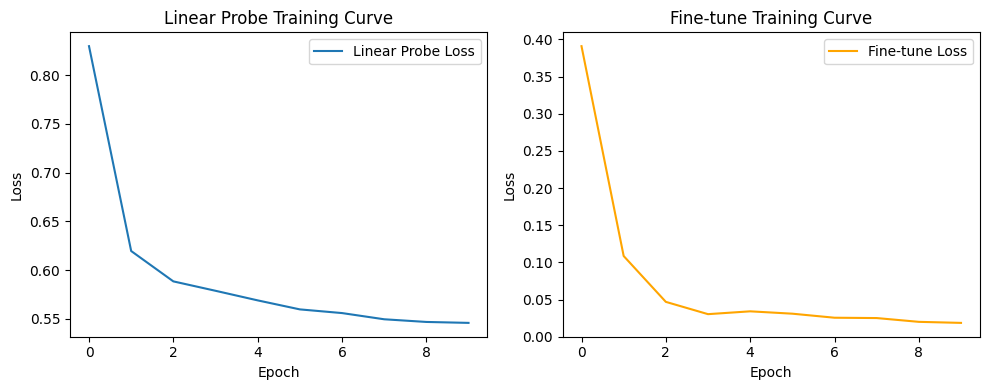

In [8]:
# Cell 8: Plot Training Curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(lp_losses, label='Linear Probe Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Linear Probe Training Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ft_losses, label='Fine-tune Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-tune Training Curve')
plt.legend()

plt.tight_layout()
plt.show()